<a href="https://www.kaggle.com/code/mahdimashayekhi/multi-modal-fashion-product-clustering?scriptVersionId=256493329" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 👚 Multi-Modal Fashion Product Clustering 🖼️
### Clustering Similar Products using Image and Textual Data

### If you find this notebook helpful, please consider giving it an UPVOTE! 👍 Your support is greatly appreciated and motivates me to share more quality content. Thank you! 🙏

## 1. Project Introduction
Welcome to this comprehensive analysis of fashion product clustering! 🚀 In the world of e-commerce, understanding which products are similar is crucial for recommendation systems, inventory management, and trend analysis. This project tackles this challenge by clustering a dataset of ~44,000 fashion products using a multi-modal approach, which means we leverage both tabular data (like product category, color, brand) and image data.

- Our main goal is to group similar products together, not just based on their descriptions, but also on their visual appearance.

- Our journey will follow these key steps:
Data Preprocessing & EDA 🧹: We'll start by cleaning our dataset, handling missing values, and performing exploratory data analysis to understand our features.

- Feature Engineering 🛠️: We'll transform our categorical features into a numerical format that machine learning models can understand.

- Image Feature Extraction with Transfer Learning (ResNet-50) 🧠: This is the core of our project! We'll use a powerful pre-trained deep learning model, ResNet-50, to "see" the images and extract their visual features.

- Dimensionality Reduction with PCA 📉: The features from ResNet-50 are very high-dimensional. We'll use PCA to reduce these dimensions while preserving most of the important information.

- Clustering Algorithms 🧩: Finally, we'll apply and compare different clustering algorithms like K-Means, Hierarchical Clustering, and DBSCAN to find the optimal groupings in our data.

Let's begin! 👇

## Importing necessary libraries

In [2]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotly.graph_objects as go
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from collections import Counter
from plotly.subplots import make_subplots
from matplotlib.image import imread
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

In [3]:
print(torch.cuda.is_available()) 
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
2
Tesla T4


## Loading the dataset 

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fashion-product-images-small/styles.csv
/kaggle/input/fashion-product-images-small/myntradataset/styles.csv
/kaggle/input/fashion-product-images-small/myntradataset/images/31973.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/30778.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/19812.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/22735.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/38246.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/16916.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/52876.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/39500.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/44758.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/59454.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/44951.jpg
/kaggle/input/fashion-product-images-small/myntradataset/images/

In [5]:
df = pd.read_csv('/kaggle/input/fashion-product-images-small/styles.csv', on_bad_lines='skip')

In [6]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [9]:
def image_exists(img_id):
    return os.path.exists(f'/kaggle/input/fashion-product-images-small/images/{img_id}.jpg')

In [10]:
image_exists('15970')

True

In [11]:
df['image_path'] = df['id'].apply(lambda x: f'/kaggle/input/fashion-product-images-small/images/{x}.jpg')
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-small/ima...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-small/ima...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-small/ima...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/fashion-product-images-small/ima...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/kaggle/input/fashion-product-images-small/ima...


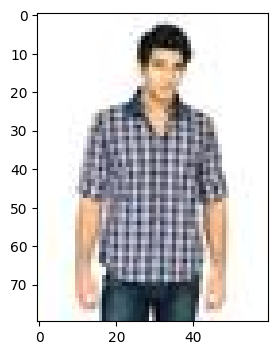

In [12]:
img = imread('/kaggle/input/fashion-product-images-small/images/15970.jpg')
plt.figure(figsize=(3, 4))
plt.imshow(img)
plt.show()

## Exploratory Data Analysis

In [13]:
df.shape

(44424, 11)

In [14]:
df['id'].nunique()

44424

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
 10  image_path          44424 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 3.7+ MB


In [16]:
df.dtypes

id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
image_path             object
dtype: object

In [17]:
df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
image_path              0
dtype: int64

In [18]:
round(df.isnull().sum() / len(df) * 100, 2)

id                    0.00
gender                0.00
masterCategory        0.00
subCategory           0.00
articleType           0.00
baseColour            0.03
season                0.05
year                  0.00
usage                 0.71
productDisplayName    0.02
image_path            0.00
dtype: float64

In [19]:
print(f"Total number of missing values: {df.isnull().sum().sum()}")

Total number of missing values: 361


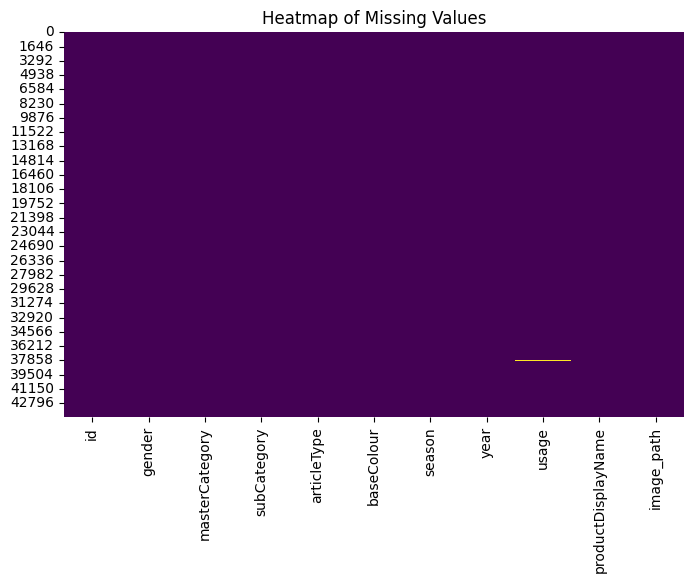

In [20]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cmap='viridis', cbar=False)
plt.title('Heatmap of Missing Values')
plt.show()

In [21]:
df[df.isna().any(axis=1)]

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
87,56489,Women,Personal Care,Nails,Nail Polish,Bronze,Spring,2017.0,NaN,Streetwear Ash Nail Polish # 31,/kaggle/input/fashion-product-images-small/ima...
92,52029,Unisex,Apparel,Topwear,Rain Jacket,Coffee Brown,Summer,2012.0,NaN,Just Natural Unisex Charcoal Rain Jacket,/kaggle/input/fashion-product-images-small/ima...
282,5402,Women,Footwear,Shoes,Sports Shoes,Purple,NaN,2011.0,Sports,Kalenji Ekiden 200 Wn Purple 2011,/kaggle/input/fashion-product-images-small/ima...
292,55001,Women,Personal Care,Lips,Lipstick,Pink,Spring,2017.0,NaN,Lakme Absolute Lip Last Day Kiss Lip Colour,/kaggle/input/fashion-product-images-small/ima...
479,57563,Women,Personal Care,Lips,Lipstick,Brown,Spring,2017.0,NaN,Lotus Herbals Pure Colours Nutty Brown Lipstic...,/kaggle/input/fashion-product-images-small/ima...
...,...,...,...,...,...,...,...,...,...,...,...
43633,56605,Women,Personal Care,Makeup,Kajal and Eyeliner,Black,Spring,2017.0,NaN,Streetwear Black Eye Liner 01,/kaggle/input/fashion-product-images-small/ima...
44079,57715,Women,Personal Care,Lips,Lip Gloss,Red,Spring,2017.0,NaN,Lotus Herbals Seduction Sappy Watermelon Lip G...,/kaggle/input/fashion-product-images-small/ima...
44224,43120,Men,Personal Care,Fragrance,Perfume and Body Mist,NaN,Spring,2017.0,NaN,GUESS by Marciano Men Eau De Toilette 50 ml,/kaggle/input/fashion-product-images-small/ima...
44227,55045,Women,Personal Care,Lips,Lipstick,Purple,Spring,2017.0,NaN,Lakme Enrich Satins Lipstick 461,/kaggle/input/fashion-product-images-small/ima...


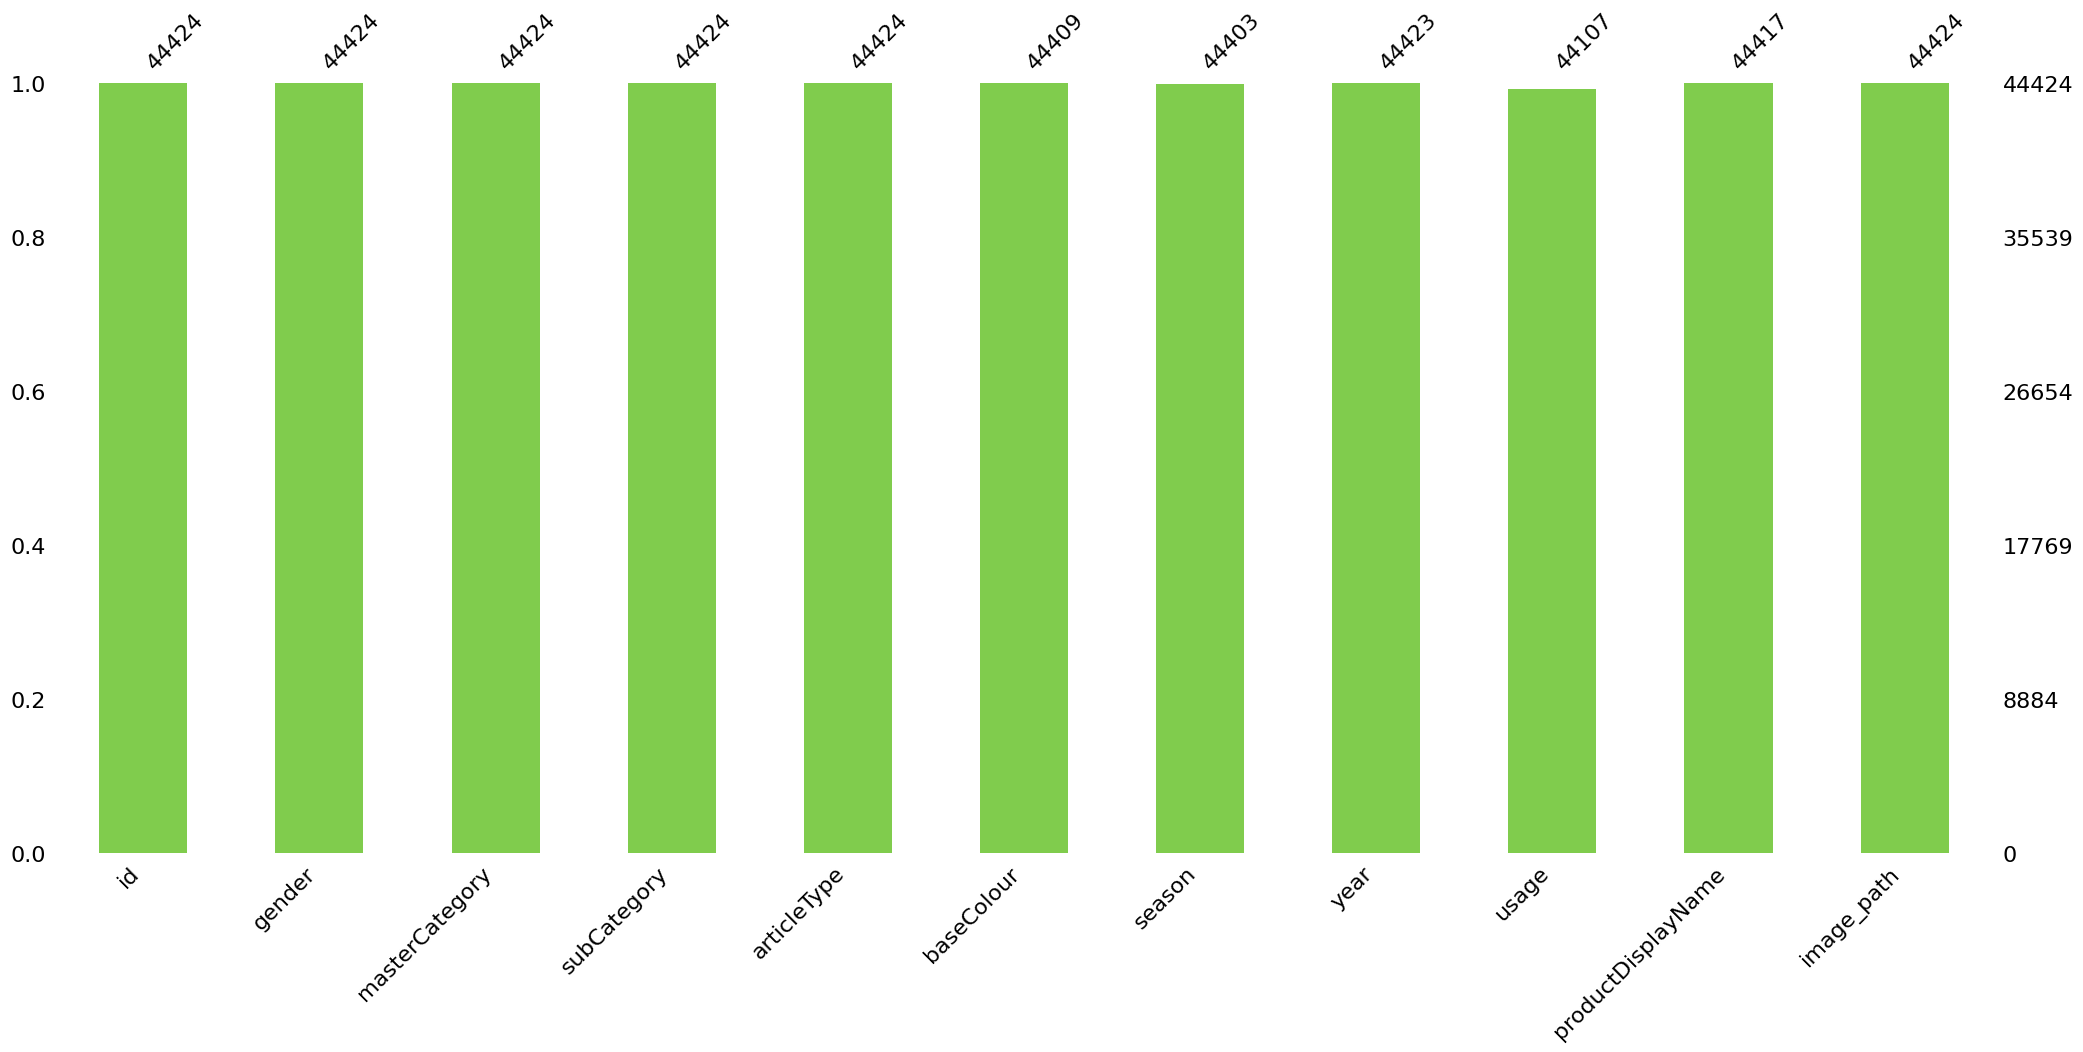

In [22]:
msno.bar(df, color=(0.5, 0.8, 0.3));

In [23]:
# Columns with missing values less than 1 percent:
# baseColour, season, year, usage 
# Missing values are random and doesn't have any pattern

In [24]:
print(f"Total number of duplicated values: {df.duplicated().sum()}")

Total number of duplicated values: 0


In [25]:
df.describe()

,id,year
count,44424.000000,44423.000000
mean,29696.334301,2012.806497
std,17049.490518,2.126480
min,1163.000000,2007.000000
25%,14768.750000,2011.000000
50%,28618.500000,2012.000000
75%,44683.250000,2015.000000
max,60000.000000,2019.000000


In [26]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

print("Numeric Columns:")
print(num_cols)
print(f"Number of numeric columns: {len(num_cols)}")
print()
print("Categorical Columns:")
print(cat_cols)
print(f"Number of categorical columns: {len(cat_cols)}")

Numeric Columns:
Index(['id', 'year'], dtype='object')
Number of numeric columns: 2

Categorical Columns:
Index(['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour',
       'season', 'usage', 'productDisplayName', 'image_path'],
      dtype='object')
Number of categorical columns: 9


In [27]:
for col in cat_cols:
    print(df[col].value_counts())
    print(df[col].nunique())
    print()

gender
Men       22147
Women     18631
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64
5

masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64
7

subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup        

In [28]:
# Detecting high-cardinality feature with threshold 50

threshold = 50

cardinality_count = df[cat_cols].nunique()
high_cardinality_features = cardinality_count[cardinality_count > threshold]
print("Features that have a lot of unique values:")
high_cardinality_features

Features that have a lot of unique values:


articleType             143
productDisplayName    31121
image_path            44424
dtype: int64

In [29]:
def plot_categorical_distributions(df: pd.DataFrame, categorical_columns: list, top_n: int = 10):
    """
    Creates an interactive Plotly figure to visualize the distribution of multiple categorical columns.

    The figure contains a pie chart and a bar chart. A dropdown menu allows switching between
    the specified columns. For columns with more categories than top_n, it groups the rest
    into an 'Others' category.

    Args:
        df (pd.DataFrame): The pandas DataFrame containing the data.
        categorical_columns (list or pd.Index): A list or pandas Index of strings with the 
                                                 names of the categorical columns to plot.
        top_n (int): The number of top categories to display before grouping into 'Others'. Default is 10.

    Returns:
        plotly.graph_objects.Figure: The interactive Plotly figure object.
    """
    if isinstance(categorical_columns, pd.Index):
        categorical_columns = categorical_columns.tolist()

    if not categorical_columns:
        print("Error: The list of categorical columns cannot be empty.")
        return None

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Pie Chart", "Count Plot"),
        specs=[[{'type': 'domain'}, {'type': 'xy'}]]
    )

    processed_data = {}

    for col in categorical_columns:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in the DataFrame. Skipping.")
            continue
        
        counts = df[col].value_counts()
        
        if len(counts) > top_n:
            top_items = counts.nlargest(top_n)
            others = pd.Series([counts.nsmallest(len(counts) - top_n).sum()], index=['Others'])
            processed_counts = pd.concat([top_items, others])
        else:
            processed_counts = counts
            
        processed_data[col] = processed_counts

    if not processed_data:
        print("Error: No valid columns to plot.")
        return None
        
    initial_col = next(iter(processed_data))
    initial_data = processed_data[initial_col]

    fig.add_trace(go.Pie(
        labels=initial_data.index,
        values=initial_data.values,
        name="Pie",
        hole=.3,
        hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>'
    ), 1, 1)

    fig.add_trace(go.Bar(
        x=initial_data.index,
        y=initial_data.values,
        name="Count",
        hovertemplate='<b>%{x}</b><br>Count: %{y}<extra></extra>'
    ), 1, 2)

    buttons = []
    for col in processed_data.keys():
        data = processed_data[col]
        buttons.append(dict(
            method='restyle',
            label=col,
            args=[
                {'labels': [data.index], 'values': [data.values], 'x': [data.index], 'y': [data.values]},
                [0, 1]
            ]
        ))

    fig.update_layout(
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.01,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )],
        title_text=f"Interactive Distribution Plot",
        title_x=0.5,
        margin=dict(t=150, b=50)
    )
    
    return fig

In [30]:
interactive_fig = plot_categorical_distributions(df, cat_cols)

if interactive_fig:
    interactive_fig.show()

In [ ]:
corrupted_images = []

print("Starting image verification process...")

for image_path in df['image_path']:
    try:
        if not os.path.exists(image_path):
            corrupted_images.append(image_path)
            continue 

        with Image.open(image_path) as img:
            img.load()

    except Exception as e:
        print(f"Could not load image: {image_path} | Error: {e}")
        corrupted_images.append(image_path)

print("\n--- Verification Complete! ---")
if not corrupted_images:
    print(" All images were loaded successfully.")
else:
    print(f"Found {len(corrupted_images)} corrupted or missing images.")
    print("List of corrupted/missing images: \n", corrupted_images)


Starting image verification process...


In [ ]:
image_paths = df['image_path'].tolist()

dimension_counts = Counter()

for path in image_paths:
    try:
        with Image.open(path) as img:
            dimension_counts[img.size] += 1
    except Exception as e:
        print(f"Could not read: {path}, Error: {e}")

print("\n--- Count Number of Unique Values ---")
if len(dimension_counts) == 1:
    print(f"All images are in same scale.")
    (width, height) = list(dimension_counts.keys())[0]
    print(f"   - Scale: {width}x{height} pixel")
    print(f"   - Ratio: {width/height:.2f}")
else:
    print(f"Differnt scale: {len(dimension_counts)} have in images!")
    for dimensions, count in dimension_counts.items():
        width, height = dimensions
        aspect_ratio = width / height if height > 0 else 0
        print(f"   - Scale: {width}x{height}  |  Counts: {count}  |  Ratio: {aspect_ratio:.2f}")

## Data Preprocessing and Cleaning

In [ ]:
# Handing missig values
colors = ['Black', 'White', 'Blue', 'Brown', 'Grey', 'Red', 'Green', 'Pinky', 'Blue', 'Purple', 'Silver', 'Yellow', 'Beige', 'Gold', 'Maroon', 'Orange', 'live', 'Multi', 'Creaml', 'Charcoal', 'Peach', 'Off White',  'Grey Melange', 'Turquoise Blue', 'Coffee Brown', 'Sea Green', 'Mushroom Brown', 'Lime Green' 'Fluorescent Green']

def extract_color(name):
    if isinstance(name, str):  
        for c in colors:
            if c.lower() in name.lower():
                return c
    return None

df['baseColour'] = df.apply(
    lambda row: extract_color(row['productDisplayName']) if pd.isnull(row['baseColour']) else row['baseColour'],
    axis=1
)

filled = df.groupby('articleType')['baseColour'].apply(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Black")
)
df['baseColour'] = filled.reset_index(level=0, drop=True)

In [ ]:
df['season'] = (
    df.groupby(['year', 'masterCategory'])['season']
      .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Spring"))
)

df = df[df['year'].notnull()]

df = df[df['productDisplayName'].notnull()]

df['usage'] = (
    df.groupby('articleType')['usage']
      .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
)

In [ ]:
df.isnull().sum()

In [ ]:
# Remove records with missing images

corrupted_index = df[df['image_path'].isin(corrupted_images)].index
df.drop(corrupted_index, inplace=True)

In [ ]:
df.shape[0]

In [ ]:
# Remove non-standard image sizes

image_paths = df['image_path'].tolist()
standard_size = (60, 80)
non_standard_images = []
counter = 0

for path in image_paths:
    try:
        with Image.open(path) as img:
            if img.size != standard_size:
                non_standard_images.append(path)
                counter += 1
    except Exception as e:
        print(f'Error while reading the image: {e}')

print(f"{counter} images have non-statndard ratio!")

In [ ]:
non_standard_index = df[df['image_path'].isin(non_standard_images)].index
df.drop(non_standard_index, inplace=True)

In [ ]:
df.shape[0]

In [ ]:
# Text feature engineering 
df['brand'] = df['productDisplayName'].str.split().str[0]

luxury_keywords = ['Nike', 'Puma', 'ADIDAS', 'United', 'Fabindia']
df['isLuxury'] = df['brand'].isin(luxury_keywords).astype(int)

In [ ]:
color_categories = {
    # Dark colors
    'Black': 'dark',
    'Navy Blue': 'dark',
    'Blue': 'dark',
    'Brown': 'dark',
    'Charcoal': 'dark',
    'Maroon': 'dark',
    'Olive': 'dark',
    'Steel': 'dark',
    'Grey': 'dark',
    'Rust': 'dark',
    'Burgundy': 'dark',
    'Bronze': 'dark',
    'Copper': 'dark',
    'Coffee Brown': 'dark',
    'Mushroom Brown': 'dark',

    # Natural colors
    'Beige': 'natural',
    'Cream': 'natural',
    'Off White': 'natural',
    'Skin': 'natural',
    'Khaki': 'natural',
    'Tan': 'natural',
    'Taupe': 'natural',
    'Grey Melange': 'natural',
    'Green': 'natural',

    # Bright colors
    'White': 'bright',
    'Red': 'bright',
    'Pink': 'bright',
    'Purple': 'bright',
    'Silver': 'bright',
    'Yellow': 'bright',
    'Gold': 'bright',
    'Orange': 'bright',
    'Peach': 'bright',
    'Lavender': 'bright',
    'Magenta': 'bright',
    'Teal': 'bright',
    'Mustard': 'bright',
    'Turquoise Blue': 'bright',
    'Sea Green': 'bright',
    'Lime Green': 'bright',
    'Fluorescent Green': 'bright',
    'Rose': 'bright',
    'Mauve': 'bright',
    'Nude': 'bright',
    'Metallic': 'bright',
    'Multi': 'bright'
}

df['colorIntensity'] = df['baseColour'].map(color_categories)
df['colorIntensity'] = df['colorIntensity'].fillna('Unknown')

In [ ]:
df['colorIntensity'].value_counts()

In [ ]:
# Categorical Encoding

onehot_cols = ['gender', 'masterCategory', 'season', 'usage', 'colorIntensity']
freq_cols = ['subCategory', 'articleType', 'baseColour', 'brand']

# One Hot Encoding for low cardinality features
onehot = OneHotEncoder(sparse_output=False, drop='first')
onehot_df = pd.DataFrame(onehot.fit_transform(df[onehot_cols]), columns=onehot.get_feature_names_out(onehot_cols))

# Frequently Encoding for high cardinality featuers
df_freq = df.copy()
for col in freq_cols:
    freq = df_freq[col].value_counts(normalize=True)
    df_freq[col + '_freq'] = df_freq[col].map(freq)

In [ ]:
df_freq = df_freq.iloc[:, -4:]
df.drop(columns=freq_cols, axis=1, inplace=True)

In [ ]:
df.drop(columns=onehot_cols, axis=1, inplace=True)

In [ ]:
onehot_df.index = df.index
df_freq.index = df.index
df = pd.concat([df, df_freq, onehot_df], axis=1)
df.head()

In [ ]:
class FashionImagesDataset(Dataset):
    def __init__(self, df, image_column, transform=None):
        self.df = df.reset_index(drop=True)  
        self.image_column = image_column
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx][self.image_column]
        try:
            with Image.open(img_path) as img:  
                img = img.convert('RGB')
                if self.transform:
                    img = self.transform(img)
                return img
        except Exception as e:
            print(f"Error loading {img_path}: {e}")  
            dummy = torch.zeros(3, 224, 224)
            return dummy

In [ ]:
# Transformations for ResNet

transform = transforms.Compose([
     transforms.Resize((224, 224)),              # ResNet expects 224x224
    transforms.ToTensor(),                       # Convert to tensor
    transforms.Normalize(                        # Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Load ResNet50 and remove final classification layer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet = models.resnet50(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.to(device)
resnet.eval()

In [ ]:
# Create Dataset and DataLoader

dataset = FashionImagesDataset(df, image_column='image_path', transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
# Extract features for all images

print("🚀 Starting feature extraction...")

# Start with smaller subset for testing
# subset_size = 100  # Start small, increase gradually
# subset = Subset(dataset, range(subset_size))  
# dataloader = DataLoader(subset, batch_size=16, shuffle=False, num_workers=0)  # num_workers=0 is safer

all_features = []
batch_counter = 0
total_images = 0

print(f"Processing {len(df)} images in batches of 64...")

with torch.no_grad():
    for batch in dataloader:
        print(f"Loading batch {batch_counter + 1}...")
        
        batch = batch.to(device)
        print(f"Batch moved to {device}, shape: {batch.shape}")
        
        # Extract features
        feats = resnet(batch)
        feats = feats.view(feats.size(0), -1)
        all_features.append(feats.cpu().numpy())
        
        total_images += batch.size(0)
        batch_counter += 1 
        
        print(f"✅ Batch {batch_counter} processed - {total_images}/{len(df)} images done")
        print(f"Feature shape for this batch: {feats.shape}")

print(f"\n🎉 Feature extraction complete!")
print(f"Total batches processed: {batch_counter}")
print(f"Total images processed: {total_images}")

In [ ]:
# Stack all features into one array

all_features = np.vstack(all_features) 
all_features.shape

In [ ]:
# Add to DataFrame

features_df = pd.DataFrame(all_features, columns=[f"img_feat_{i}" for i in range(all_features.shape[1])])
df = pd.concat([df.reset_index(drop=True), features_df], axis=1)
df.head()

In [ ]:
image_features = df.filter(regex='img_feat_')
metadata = df[['id', 'productDisplayName', 'image_path']]

In [ ]:
image_features.head()

In [ ]:
metadata.head()

In [ ]:
df.drop(['id', 'productDisplayName', 'image_path'], axis=1, inplace=True)

In [ ]:
# Feature Scaling

scaler = StandardScaler()
image_features_scaled = pd.DataFrame(scaler.fit_transform(image_features), columns=image_features.columns)
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [ ]:
# 1. Apply PCA without specifying the number of components
pca = PCA()
pca.fit(image_features_scaled)

# 2. Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Add a line for 95% variance
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.legend()
plt.show()

In [ ]:
# Apply PCA with specific number on images 
pca = PCA(n_components=0.95, random_state=42)
image_featues_reduced = pd.DataFrame(pca.fit_transform(image_features_scaled), columns=[f'img_PC_{i+1}' for i in range(397)])

In [ ]:
print(f"Shape of original dataset is: {image_features_scaled.shape}")
print(f"Shape of reduced dataset is: {image_featues_reduced.shape}")

In [ ]:
df_scaled.drop(image_features_scaled, axis=1, inplace=True)
prepared_df = pd.concat([df_scaled, image_featues_reduced], axis=1)
prepared_df.head()

In [ ]:
prepared_df.shape

## Modeling and Evaluating

In [ ]:
# KMeans clustering
# Start with ellbow method

inertia_values = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(prepared_df)
    inertia_values.append(kmeans.inertia_)

In [ ]:
inertia_values = pd.Series(inertia_values, index=range(2, 16))

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(inertia_values, color='Red')
plt.plot(inertia_values, color='Blue')
plt.title('Ellbow Plot For Finding Best Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(2, 16))
plt.grid(axis='x', alpha=0.2)
plt.show()

In [ ]:
# For this business I prefer 6 clusters

kmeans6 = KMeans(n_clusters=6, init='k-means++', n_init='auto', random_state=42)
kmeans6.fit(prepared_df)

In [ ]:
kmeans6.labels_

In [ ]:
kmeans6.cluster_centers_

In [ ]:
prepared_df.columns

In [ ]:
cluster_centers = pd.DataFrame(kmeans6.cluster_centers_, columns=prepared_df.columns)
cluster_centers

In [ ]:
pca_vis = PCA(n_components=2)
features_2d = pca_vis.fit_transform(prepared_df)

plt.scatter(features_2d[:,0], features_2d[:,1], c=kmeans6.labels_, cmap='tab10', s=10, alpha=0.3)
plt.title("Clusters visualized in 2D PCA space")
plt.show()

In [ ]:
pca_full = PCA().fit(prepared_df)
explained = np.cumsum(pca_full.explained_variance_ratio_)

n_components_80 = np.argmax(explained >= 0.80) + 1
print(f"Number of components for 80% variance: {n_components_80}")

In [ ]:
plt.plot(explained, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Variance Explained")
plt.show()

In [ ]:
pca = PCA(n_components=n_components_80, random_state=42)
df_with_75_features = pd.DataFrame(pca.fit_transform(prepared_df), columns=[f'pca_{i + 1}' for i in range(75)])

In [ ]:
df_with_75_features.head()

In [ ]:
kmeans6 = KMeans(n_clusters=6, init='k-means++', n_init='auto', random_state=42)
kmeans6.fit(df_with_75_features)

In [ ]:
closest, _ = pairwise_distances_argmin_min(kmeans6.cluster_centers_, df_with_75_features)

for i, idx in enumerate(closest):
    print(f"Cluster {i}, Representative Image: {metadata.iloc[idx]['image_path']}")

In [ ]:
labels = kmeans6.labels_

for cluster_id in range(6): 
    cluster_indices = np.where(labels == cluster_id)[0]  
    sample_indices = random.sample(list(cluster_indices), min(10, len(cluster_indices)))  
    
    print(f"\nCluster {cluster_id + 1} Sample Images:")
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(sample_indices):
        img_path = metadata.iloc[idx]['image_path']
        img = Image.open(img_path)
        plt.subplot(1, 10, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()


In [ ]:
center_clusters_image = ['./images/53527.jpg', './images/14556.jpg', './images/36503.jpg', './images/41050.jpg', './images/54032.jpg', './images/26300.jpg']

fig, axes = plt.subplots(1, len(center_clusters_image), figsize=(18, 3))

for i, image in enumerate(center_clusters_image):
    try:
        img = Image.open(image)
        axes[i].imshow(img)
        axes[i].axis("off")
        
        # Get product name from dataframe
        product_name = metadata.loc[metadata['image_path'] == image, 'productDisplayName'].values
        if len(product_name) > 0:
            axes[i].set_title(product_name[0], fontsize=9)  # show product name
        else:
            axes[i].set_title(f"Cluster {i+1}", fontsize=9)
            
    except Exception as e:
        print(f"Something is wrong with {image}: {e}")

plt.tight_layout()
plt.show()

In [ ]:
# Cluster 1: Women's and men's underwear
# Cluster 2: All kinds of shoes and slippers
# Cluster 3: Women's kurta dress
# Cluster 4: Classic and sports watches
# Cluster 5: Accessories and peripherals
# Cluster 6: Types of men's t-shirts

In [ ]:
# create an empty list to hold many silhouette score values
silhouette_scores = []

# create 2 - 15 clusters, and add the silhouette scores to the list
for k in range(2, 16):
    print(f"Start training a kmeans with {k} clusters:")
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(prepared_df)
    print('Calculate Silhoutte Score...')
    silhouette_scores.append(silhouette_score(prepared_df, kmeans.labels_, metric='euclidean', sample_size=10000))
    print(f"Kmeans with {k} clusters has {silhouette_scores[k - 2]}")

In [ ]:
# plot the silhouette scores

# turn the list into a series for plotting
silhouette_series = pd.Series(silhouette_scores, index=range(2, 16))

# plot the data
silhouette_series.plot(marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 16))
plt.title("Number of Clusters vs. Silhouette Score");

In [ ]:
# Agglomerative Clustering

sample_size = 5000

sample_indices = np.random.choice(prepared_df.shape[0], sample_size, replace=False)
sample_features = prepared_df.iloc[sample_indices, :]
sample_labels = kmeans.labels_[sample_indices]

matrix_linkage = linkage(sample_features, method='ward', metric='euclidean')
dendrogram_info = dendrogram(matrix_linkage)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance");

In [ ]:
# This algorithm needs almost 15GB RAM 
# agg5 = AgglomerativeClustering(5)
# agg5.fit(prepared_df)

# Counter(agg5.labels_)

In [ ]:
# Create a cluster map of the model
sns.clustermap(prepared_df, method='ward', cmap='RdBu', figsize=(8, 6), xticklabels=prepared_df.columns)
plt.show()